Phase 1 -->  Data Inspection & Basic Cleaning

Libraries imported successfully!

Dataset loaded successfully!

First 5 Rows of Dataset:

                             text      intent  emotion
0             I feel so sad today     sadness      sad
1             I can't stop crying     sadness      sad
2             I feel empty inside  depression  despair
3  Nothing makes me happy anymore  depression      sad
4               I feel so anxious     anxiety     fear
Dataset shape:
(49, 3)
Coulumns name:
Index(['text', 'intent', 'emotion'], dtype='object')
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     49 non-null     object
 1   intent   49 non-null     object
 2   emotion  49 non-null     object
dtypes: object(3)
memory usage: 1.3+ KB
None

Missing Values:

text       0
intent     0
emotion    0
dtype: int64

Missing values rem

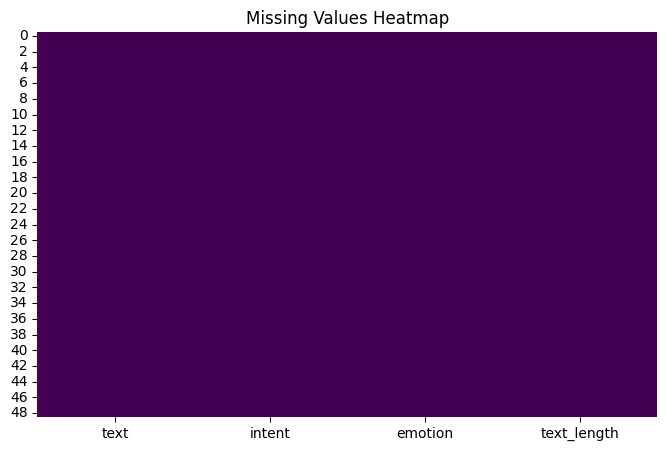


Unique Intent Labels:

['sadness' 'depression' 'anxiety' 'stress' 'loneliness' 'anger'
 'low_self_esteem' 'sleep_issues' 'seeking_help' 'positive' 'confusion']

Unique Emotion Labels:

['sad' 'despair' 'fear' 'frustrated' 'exhausted' 'angry' 'anxious'
 'confused' 'hopeful' 'happy']

Number of Empty Text Rows:
0

Cleaned dataset saved successfully!

PHASE 1 COMPLETED SUCCESSFULLY

Final Dataset Shape: (49, 4)

Tasks Completed:
1. Dataset Loaded
2. Dataset Inspected
3. Missing Values Removed
4. Duplicate Rows Removed
5. Text Length Analysis Done
6. Visualization
7. Cleaned Dataset Saved


In [ ]:
print ('Phase 1 -->  Data Inspection & Basic Cleaning\n')
#load libraries
#Data handling
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')
# Display all columns
pd.set_option('display.max_columns', None)
print("Libraries imported successfully!")


#load data
df = pd.read_csv("../data/dataset.csv")
print("\nDataset loaded successfully!")

#data overview
print("\nFirst 5 Rows of Dataset:\n")
print(df.head())
#data shape
print("Dataset shape:")
print(df.shape)

#data structure
print("Coulumns name:")
print(df.columns)

#dataset info
print("Dataset Information:")
print(df.info())

#missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

#remove missing values
df.dropna(inplace=True)
print("\nMissing values removed successfully!")

#check duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of Duplicate Rows: {duplicates}")

#remove duplicates
df.drop_duplicates(inplace=True)
print("\nDuplicate rows removed successfully!")

#data shape after cleaning
print("\nDataset Shape After Cleaning:")
print(df.shape)

#random sample rows
print("\nRandom Sample Rows:\n")
print(df.sample(5))


#basic statistics
print("\nBasic Statistics:\n")
print(df.describe(include='all'))

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.lower().str.strip()

print("\nBasic text cleaning completed!")

#text length analysis
if 'text' in df.columns:

    # Create text length column
    df['text_length'] = df['text'].apply(len)

    print("\nText Length Statistics:\n")
    print(df['text_length'].describe())
if 'text_length' in df.columns:

    print("\nShortest Messages:\n")
    print(df.nsmallest(5, 'text_length')[['text', 'text_length']])
if 'text_length' in df.columns:

    print("\nLongest Messages:\n")
    print(df.nlargest(5, 'text_length')[['text', 'text_length']])

#visualize missing values
plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

#check unique valuse
if 'intent' in df.columns:
    print("\nUnique Intent Labels:\n")
    print(df['intent'].unique())

if 'emotion' in df.columns:
    print("\nUnique Emotion Labels:\n")
    print(df['emotion'].unique())

#check empty rows
if 'text' in df.columns:
    empty_rows = df[df['text'].str.len() == 0]
    print("\nNumber of Empty Text Rows:")
    print(len(empty_rows))

#save clean dataset
df.to_csv("../data/cleaned_dataset.csv", index=False)
print("\nCleaned dataset saved successfully!")

#final summary
print("\n===================================================")
print("PHASE 1 COMPLETED SUCCESSFULLY")
print("===================================================")

print(f"\nFinal Dataset Shape: {df.shape}")

print("\nTasks Completed:")
print("1. Dataset Loaded")
print("2. Dataset Inspected")
print("3. Missing Values Removed")
print("4. Duplicate Rows Removed")
print("5. Text Length Analysis Done")
print("6. Visualization")
print("7. Cleaned Dataset Saved")
print ('Phase 2 --> Explanatory Data Analysis\n')
#import libraries
from collections import Counter
#download wordcloud
from wordcloud import WordCloud

#load cleaned dataset
df = pd.read_csv("../data/cleaned_dataset.csv")
print("\nDataset loaded successfully!")

#dataset shape
print("\nDataset Shape:")
print(df.shape)
#dataset info
print("Dataset Information:")
print(df.info())

#intent distribution analysis
if 'intent' in df.columns:
    print("\nIntent Counts:\n")
    print(df['intent'].value_counts())
    print("\nNumber of Unique Intents:")
    print(df['intent'].nunique())

#intent distribution visualization
plt.figure(figsize=(12, 6))
df['intent'].value_counts().plot(
    kind='bar'
)
plt.title("Intent Distribution")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig("../results/intent_distribution.png")
plt.show()

#emotion distribution analysis
if 'emotion' in df.columns:
    print("\nEmotion Counts:\n")
    print(df['emotion'].value_counts())
    print("\nNumber of Unique Emotions:")
    print(df['emotion'].nunique())

#emotion distribution visualization
plt.figure(figsize=(8, 8))
df['emotion'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Emotion Distribution")
plt.ylabel("")
plt.savefig("../results/emotion_distribution.png")
plt.show()

#text length analysis
if 'text' in df.columns:

    # Create text length column
    df['text_length'] = df['text'].apply(len)

    print("\nText Length Statistics:\n")
    print(df['text_length'].describe())
if 'text_length' in df.columns:

    print("\nShortest Messages:\n")
    print(df.nsmallest(5, 'text_length')[['text', 'text_length']])
if 'text_length' in df.columns:

    print("\nLongest Messages:\n")
    print(df.nlargest(5, 'text_length')[['text', 'text_length']])

#text length visualization
plt.figure(figsize=(10, 5))
plt.hist(df['text_length'], bins=30)
plt.title("Text Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.savefig("../results/text_length_visualization.png")
plt.show()

#most common words
print('Most common words:')
all_words = " ".join(df['text'])
words = all_words.split()
word_freq = Counter(words)
common_words = word_freq.most_common(25)
print(common_words)

#convert to dataframe
common_df = pd.DataFrame(
    common_words,
    columns=['Word', 'Frequency']
)
print('Data Frame:')
print(common_df)

#common words graphical visualization
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Frequency',
    y='Word',
    data=common_df
)
plt.title("Top 25 Most Common Words")
plt.savefig("../results/common_words_visualization.png")
plt.show()

#wordcloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_words)
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of User Messages")
plt.savefig("../results/wordcloud.png")
plt.show()

#AVERAGE MESSAGE LENGTH PER EMOTION
if 'emotion' in df.columns and 'text_length' in df.columns:
    avg_length = df.groupby('emotion')['text_length'].mean()
    print("\nAverage Message Length Per Emotion:\n")
    print(avg_length)

#visualization 
plt.figure(figsize=(10, 5))
avg_length.plot(kind='bar')
plt.title("Average Message Length Per Emotion")
plt.xlabel("Emotion")
plt.ylabel("Average Length")
plt.xticks(rotation=45)
plt.savefig("../results/average_message_length.png")
plt.show()

#save updated dataset
df.to_csv("../data/eda_processed_dataset.csv", index=False)
print("\nEDA processed dataset saved successfully!")

#final summary
print("\n===================================================")
print("PHASE 2 COMPLETED SUCCESSFULLY")
print("===================================================")
print(f"\nFinal Dataset Shape: {df.shape}")
print("\nTasks Completed:")
print("1. Dataset Loaded")
print("2. Intent Distribution Analysis")
print("3. Emotion Distribution Analysis")
print("4. Text Length Analysis")
print("5. Common Word Analysis")
print("6. WordCloud Visualization")
print("7. Correlation Analysis")
print("8. Graphs Saved")
print("9. EDA Processed Dataset Saved")